# Bounding the trend book

The always-on 4-week books, per coin and market, are the lane's headline. Before they go in a write-up, bound how uncertain their Sharpe is and see how they behave in the crashes trend is meant to earn through.

Block bootstrap the weekly net returns for the Sharpe, the share of paths ending above zero and the drawdown distribution. Then read the cumulative return through the known breaks, and the Sharpe year by year.

## Setup

Load the shared book and build the two 4-week books, per coin and market, sized for equal risk on \$10M coins.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qp_research import costs, gate, panel, plot
from qp_research.book import Book
from qp_research.plot import BLUE, ORANGE
import signals
from signals import sharpe

warnings.filterwarnings('ignore')
plot.style()

p = panel.load()
tb = Book(p, costs.Provisional())
per_coin = tb.run(signals.per_coin(p, 4)).net
market = tb.run(signals.market(p, 4)).net
print(f'market {sharpe(market):.2f}   per_coin {sharpe(per_coin):.2f}   weeks {len(per_coin)}')

market 0.80   per_coin 0.85   weeks 336


## How uncertain is the Sharpe

Resample the weekly net returns in 8-week blocks, 5000 draws. Read the 5th, 50th and 95th percentile of the bootstrapped Sharpe, the share of paths that end above zero, and the median and 5th percentile of the worst drawdown. Blocks keep the short-run autocorrelation intact.

In [2]:
rows = []
for name, x in [('market', market), ('per_coin', per_coin)]:
    rows.append({'book': name, 'Sharpe': sharpe(x), **gate.bootstrap(x)})
print(pd.DataFrame(rows).set_index('book').round(2))

          Sharpe  sharpe 5%  sharpe 50%  sharpe 95%  ends above zero  \
book                                                                   
market      0.80       0.29        0.86        1.42             0.99   
per_coin    0.85       0.36        0.92        1.47             1.00   

          drawdown 50%  drawdown 5%  
book                                 
market           -0.93        -1.66  
per_coin         -0.60        -1.02  


The edge is real but imprecise. Both books put the 5th percentile of the bootstrapped Sharpe above zero, 0.29 for the market and 0.36 per coin, and end above zero in 99% and 100% of paths. The interval is wide, 0.29 to 1.42 for the market book, so the point estimate carries a large error.

The drawdowns are deep. Summed in weekly returns, the median path's worst drawdown is 0.60 per coin and 0.93 for the market book, and one path in twenty falls further than 1.02 and 1.66.

## Through the crashes

Cumulative net return of each book across the sample's known breaks. Trend is meant to earn in these.

In [3]:
windows = {'May 2021 flush': ('2021-05-01', '2021-05-31'), 'LUNA 2022': ('2022-05-01', '2022-06-30'),
           'FTX 2022': ('2022-11-01', '2022-11-30'), 'Mar 2023 depeg': ('2023-03-01', '2023-03-31'),
           'Aug 2024 unwind': ('2024-08-01', '2024-08-18')}
rows = []
for wn, (a, b) in windows.items():
    rows.append({'window': wn, 'weeks': len(market.loc[a:b]),
                 'market %': market.loc[a:b].sum() * 100, 'per_coin %': per_coin.loc[a:b].sum() * 100})
print(pd.DataFrame(rows).set_index('window').round(1))

                 weeks  market %  per_coin %
window                                      
May 2021 flush       5      63.8       -16.0
LUNA 2022            9      69.3        63.3
FTX 2022             4     -27.2        -1.3
Mar 2023 depeg       4     -13.5        -6.6
Aug 2024 unwind      3      18.2         5.1


Trend's crash behaviour is the textbook shape. It earns large in sustained crashes, the market book up 64% through the May 2021 flush and 69% through the LUNA collapse, per coin up 63% through LUNA. It loses in sharp reversals, the market book down 27% through the FTX weeks and 14% through the March 2023 depeg, where price snapped back before the signal could turn. Per coin was flatter through both, near minus 1 and minus 7.

The one split is May 2021, where the market book caught the flush but per coin lost 16%, the coins scattered while the index fell. Crisis alpha in one-way moves, whipsaw losses when a crash reverses.

## Year by year

      market  per_coin
year                  
2020   -0.64      1.07
2021    1.74      1.70
2022    0.77      0.80
2023    1.07      0.83
2024    0.44      0.25
2025    1.28      1.16
2026   -0.54     -0.65


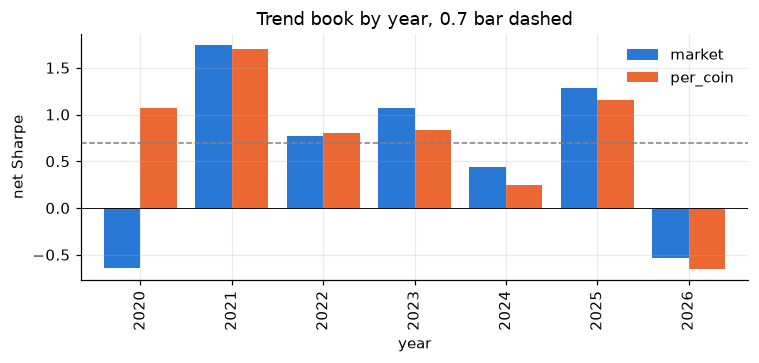

In [4]:
yr = pd.DataFrame({'market': market.groupby(market.index.year).apply(sharpe),
                   'per_coin': per_coin.groupby(per_coin.index.year).apply(sharpe)}).round(2)
yr.index.name = 'year'
print(yr)
fig, ax = plt.subplots(figsize=(7, 3.4))
yr.plot.bar(ax=ax, color=[BLUE, ORANGE], width=0.8)
ax.axhline(0, color='k', lw=0.6); ax.axhline(0.7, color='grey', ls='--', lw=1)
ax.set_ylabel('net Sharpe'); ax.set_title('Trend book by year, 0.7 bar dashed')
ax.legend(frameon=False); plt.tight_layout(); plt.show()

Only 2026 is negative in both books, and 2020 for the market alone. Every other year clears zero and most clear 0.7. The result does not lean on a single year.

## Verdict

The trend book is a real but loosely measured premium. The Sharpe is 0.80 for the market book and 0.85 per coin, with a bootstrap floor near 0.3 and a ceiling near 1.4, positive in essentially every resample. The drawdowns that come with it are deep. Its crash profile is classic trend, large gains in sustained moves and whipsaw losses when a crash reverses. Only 2026 loses across the board.